In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import Dataset

In [78]:
df = pd.read_csv('dataset/california_housing_dataset.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [79]:
# Remove data points which have ['median_house_value'] > 500000
df_loc = df[df['median_house_value'].astype(int) < 500000].copy()
df_loc.shape

(19648, 10)

In [80]:
df_loc.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [81]:
#Fill NA value into ['total_bedrooms']
df_loc['total_bedrooms'] = df_loc['total_bedrooms'].fillna(df_loc['total_bedrooms'].median())
df_loc.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [68]:
df_loc.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,-119.562378,35.651872,28.373066,2620.337693,538.590798,1441.368485,501.192488,3.676411,192055.328583
std,2.005760,2.150066,12.504050,2182.371939,420.525548,1144.075196,383.391367,1.570602,97110.854998
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,299.000000,796.000000,282.000000,2.526300,116475.000000
50%,-118.500000,34.270000,28.000000,2111.000000,436.000000,1179.000000,411.000000,3.449050,173600.000000
75%,-117.990000,37.730000,37.000000,3121.000000,644.250000,1746.250000,606.000000,4.582500,247900.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,499100.000000


In [69]:
def calculate_right_skewed_variability(data, column_name):

    # Drop missing data
    data_clean = data.dropna()

    mean_val = np.mean(data_clean)
    std_val = np.std(data_clean, ddof=1)

    cv_parametric = std_val / mean_val #Coefficient of Variance


    # Apply QCV
    q1, q2, q3 = np.percentile(data_clean, [25, 50, 75])
    iqr = q3 - q1 # Interquartile Range
    qcv_robust = iqr / (q3 + q1) # Quartile Coefficient of Variance

    # Apply Bowley Skewness
    bowley_skew = (q3 + q1 - 2 * q2) / iqr

    # Apply Log-Space Standard Deviation (Reccomend for ML)
    log_data = np.log1p(data_clean)
    log_std = np.std(log_data, ddof=1)

    return {
        'Feature': column_name,
        'Mean': round(mean_val, 2),
        'Median (Q2)': round(q2, 2),
        'CV (Std/Mean)': round(cv_parametric, 4), 
        'QCV (Robust CV)': round(qcv_robust, 4), 
        'Bowley Skewness': round(bowley_skew, 4),
        'Log-Std': round(log_std, 4)
    }

In [70]:
target_columns = ['median_income', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_house_value']
results = [calculate_right_skewed_variability(df_loc[col_name], col_name) for col_name in target_columns]

In [71]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

           Feature      Mean  Median (Q2)  CV (Std/Mean)  QCV (Robust CV)  Bowley Skewness  Log-Std
     median_income      3.68         3.45         0.4272           0.2892           0.1025   0.3307
       total_rooms   2620.34      2111.00         0.8329           0.3692           0.2002   0.7484
    total_bedrooms    538.59       436.00         0.7808           0.3660           0.2064   0.7194
        population   1441.37      1179.00         0.7937           0.3738           0.1939   0.7342
        households    501.19       411.00         0.7650           0.3649           0.2037   0.7237
median_house_value 192055.33    173600.00         0.5056           0.3607           0.1307   0.5321


### Correlative Matrix Checking

<Axes: title={'center': 'Heatmap showing the Correlations between all features'}>

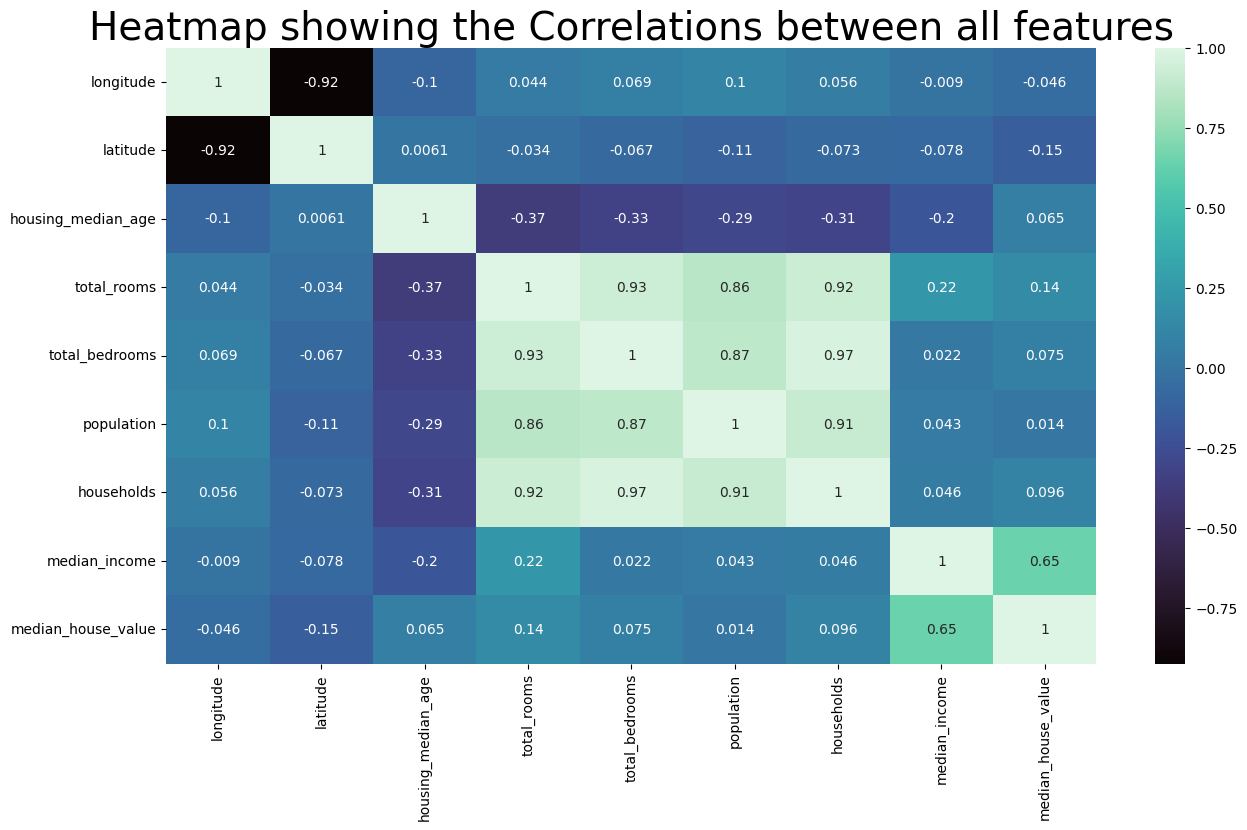

In [82]:
corr_df = df_loc.drop(['ocean_proximity'], axis=1)
plt.figure(figsize=(15, 8))
plt.title("Heatmap showing the Correlations between all features", fontsize=28)
sns.heatmap(corr_df.corr(), annot=True, cmap='mako')

### Ratio Feature Engineering

In [83]:
df_loc['total_rooms_per_household'] = df_loc['total_rooms'] / df_loc['households']
df_loc['total_bedrooms_per_household'] = df_loc['total_bedrooms'] / df_loc['households']
df_loc['population_per_household'] = df_loc['total_bedrooms'] / df_loc['households']
df_loc['total_bedrooms_per_total_rooms'] = df_loc['total_bedrooms'] / df_loc['total_rooms']

In [92]:
df_loc["log_median_income"] = np.log1p(df_loc["median_income"])
df_loc["log_households"] = np.log1p(df_loc["households"])
df_loc["log_rooms_per_household"] = np.log1p(df_loc["total_rooms_per_household"])
df_loc["log_population_per_household"] = np.log1p(df_loc["population_per_household"])
df_loc["log_median_house_value"] = np.log1p(df_loc["median_house_value"])
df_loc["log_total_bedrooms_per_total_rooms"] = np.log1p(df_loc["total_bedrooms_per_total_rooms"])

In [85]:
df_loc = df_loc.drop(['total_rooms', 'total_bedrooms', 'population', 'total_bedrooms_per_household'], axis=1)

In [99]:
df_loc.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity,total_rooms_per_household,population_per_household,total_bedrooms_per_total_rooms,log_median_income,log_households,log_rooms_per_household,log_population_per_household,log_median_house_value,log_total_bedrooms_per_total_rooms
0,-122.23,37.88,41.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,0.146591,2.232720,4.844187,2.077455,0.704982,13.022766,0.136793
1,-122.22,37.86,21.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,0.155797,2.230165,7.037906,1.979364,0.678988,12.789687,0.144790
2,-122.24,37.85,52.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,0.129516,2.111110,5.181784,2.228738,0.729212,12.771673,0.121789
3,-122.25,37.85,52.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,0.184458,1.893579,5.393628,1.919471,0.729025,12.740520,0.169286
4,-122.25,37.85,52.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,0.172096,1.578195,5.560682,1.985385,0.732888,12.743154,0.158793


<Axes: title={'center': 'Heatmap showing the Correlations between all features'}>

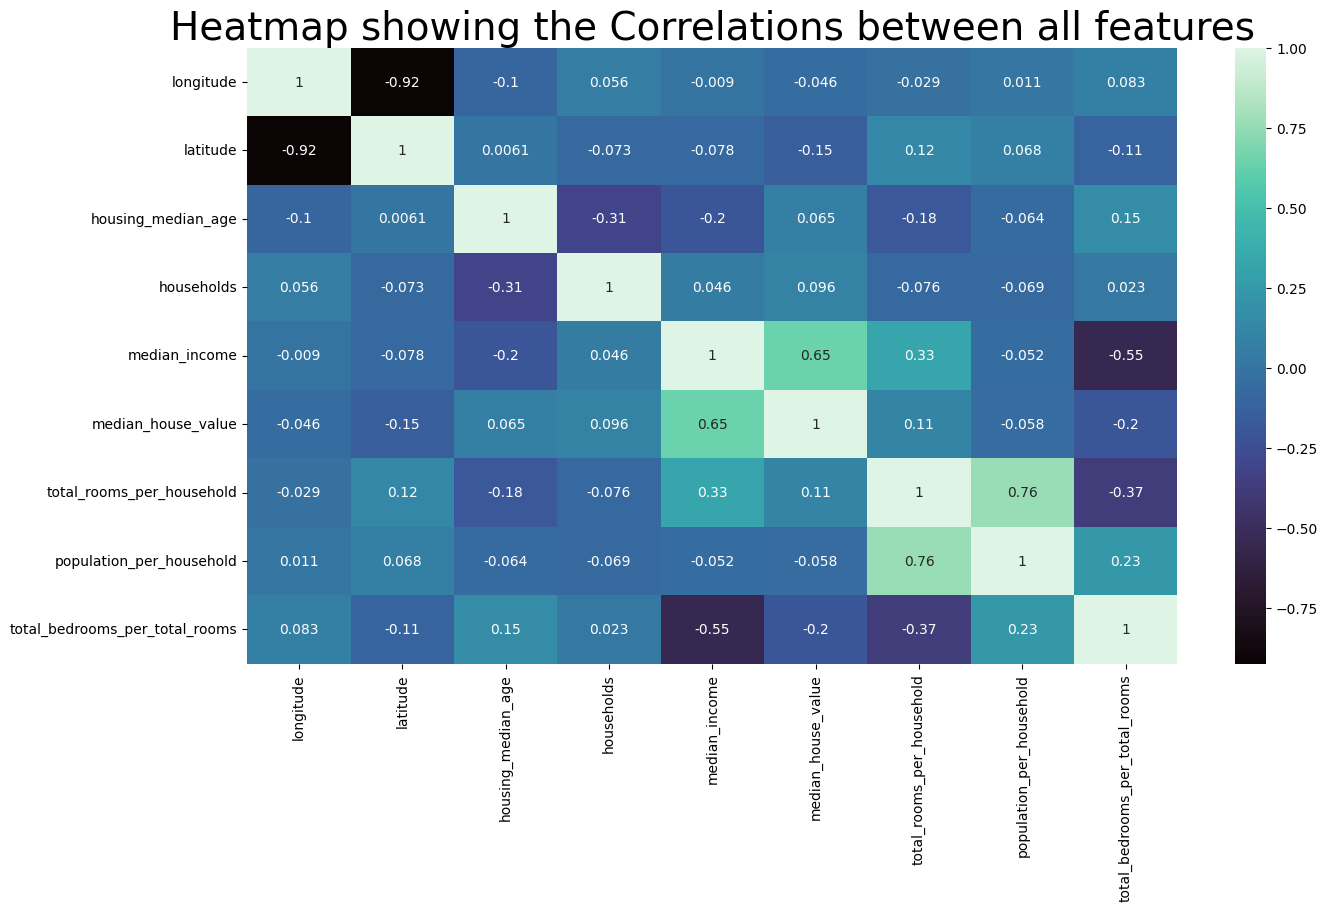

In [86]:
corr_df = df_loc.drop(['ocean_proximity'], axis=1)
plt.figure(figsize=(15,8))
plt.title("Heatmap showing the Correlations between all features", fontsize=28)
sns.heatmap(corr_df.corr(), annot=True, cmap='mako')

### Visualize Data

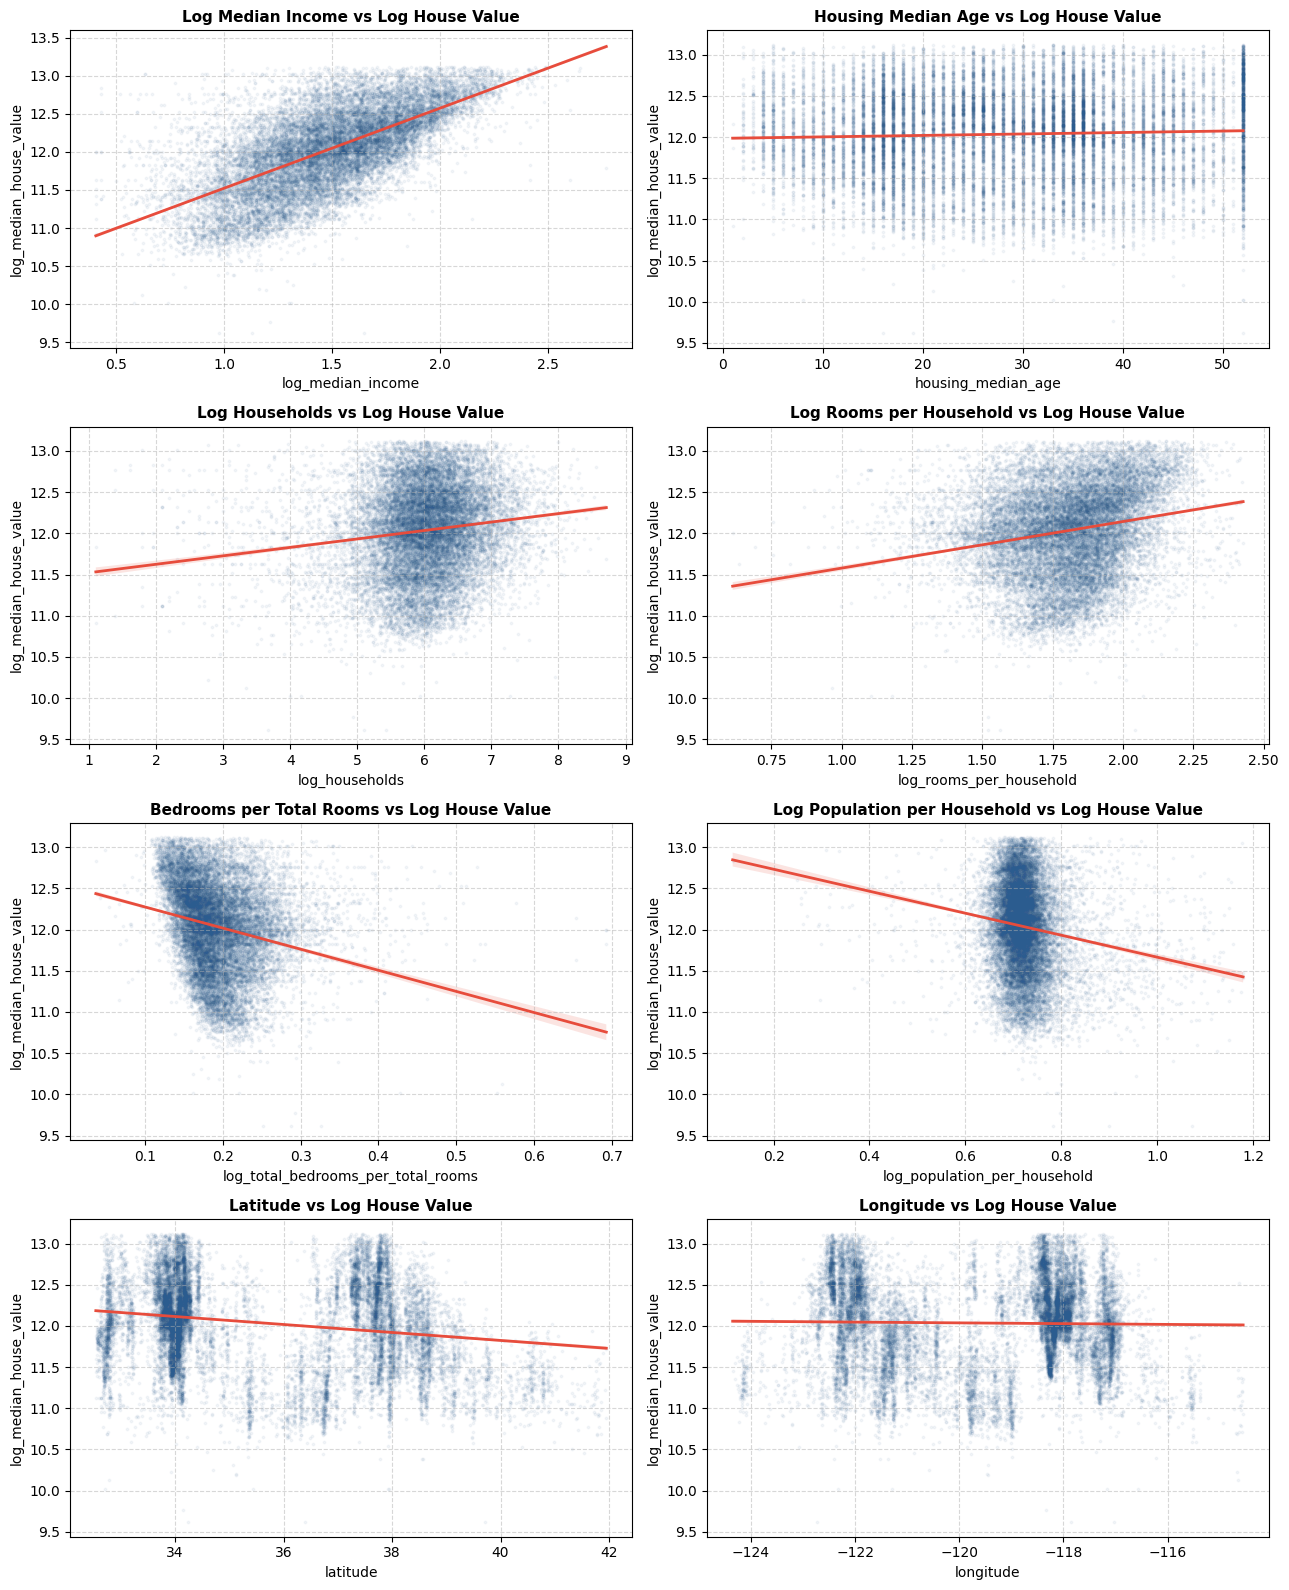

In [98]:
df_viz = df_loc[
    (df_loc['total_rooms_per_household'] < df_loc['total_rooms_per_household'].quantile(0.99)) &
    (df_loc['population_per_household'] < df_loc['population_per_household'].quantile(0.99))
].copy()

features_to_plot = [
    ('log_median_income', 'Log Median Income'),
    ('housing_median_age', 'Housing Median Age'),
    ('log_households', 'Log Households'),
    ('log_rooms_per_household', 'Log Rooms per Household'),
    ('log_total_bedrooms_per_total_rooms', 'Bedrooms per Total Rooms'),
    ('log_population_per_household', 'Log Population per Household'),
    ('latitude', 'Latitude'),
    ('longitude', 'Longitude')
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for idx, (col, title) in enumerate(features_to_plot):
    sns.regplot(
        data=df_viz, x=col, y='log_median_house_value', ax=axes[idx],
        scatter_kws={'alpha': 0.05, 's': 3, 'color': '#2b5c8f'},
        line_kws={'color': '#e74c3c', 'linewidth': 2}
    )
    axes[idx].set_title(f'{title} vs Log House Value', fontsize=11, fontweight='bold')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Scale and Train Data

In [103]:
feature_cols = [
    'log_median_income',
    'housing_median_age',
    'log_households',
    'log_rooms_per_household',
    'log_total_bedrooms_per_total_rooms',
    'log_population_per_household',
    'latitude',
    'longitude'
]

In [105]:
y = df_loc["log_median_house_value"].values.reshape(-1, 1)
X = df_loc[feature_cols].values

In [ ]:
np.random.seed(42)
n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

In [108]:
train_size = int(n_samples * 0.8)
train_idx, test_idx = indices[:train_size], indices[train_size:]

In [124]:
X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train_raw, y_test_raw = y[train_idx], y[test_idx]

In [114]:
X_train_mean = np.mean(X_train_raw, axis=0)
X_train_std = np.std(X_train_raw, axis=0)

In [117]:
X_train_scaled = (X_train_raw - X_train_mean) / X_train_std
X_test_scaled = (X_test_raw - X_train_mean) / X_train_std

In [123]:
X_train = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

In [125]:
thetha = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train_raw

### Predict Data

In [126]:
y_pred = X_test @ thetha

In [129]:
y_pred_real_test = np.expm1(y_pred)
y_test_real = np.expm1(y_test_raw)

test_rmse = np.sqrt(np.mean((y_pred_real_test - y_test_real) ** 2))
print(f"RMSE: ${test_rmse:,.2f}")

RMSE: $61,255.70
